##Tiny NeRF
This is a simplied version of the method presented in *NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis*

[Project Website](http://www.matthewtancik.com/nerf)

[arXiv Paper](https://arxiv.org/abs/2003.08934)

[Full Code](github.com/bmild/nerf)

Components not included in the notebook
*   5D input including view directions
*   Hierarchical Sampling



NeRF 볼룸렌더링 원리
- 샘플들이 빛이 지나가는 순서대로 존재, 각각의 샘플까지 도달하는 '투과율'을 누적곱 형태로 계산(자기자신 불포함)
- 배타적 누적곱 사용(exclusive cumulative product)  

In [1]:
import os, sys         # 시스템/환경 설정
import torch            # 딥러닝 핵심 라이브러리
from tqdm import tqdm   # 진행률 표시 (프로그레스 바)
import numpy as np      # 배열 및 수치 연산
import matplotlib.pyplot as plt  # 데이터 시각화

In [2]:
if not os.path.exists('tiny_nerf_data.npz'):
    !wget http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz

--2026-06-19 05:44:00--  http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
Resolving cseweb.ucsd.edu (cseweb.ucsd.edu)... 132.239.8.30
Connecting to cseweb.ucsd.edu (cseweb.ucsd.edu)|132.239.8.30|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cseweb.ucsd.edu//~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz [following]
--2026-06-19 05:44:00--  https://cseweb.ucsd.edu//~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
Connecting to cseweb.ucsd.edu (cseweb.ucsd.edu)|132.239.8.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12727482 (12M)
Saving to: ‘tiny_nerf_data.npz’

tiny_nerf_data.npz  100%[===================>]  12.14M  3.85MB/s    in 3.2s    

2026-06-19 05:44:04 (3.85 MB/s) - ‘tiny_nerf_data.npz’ saved [12727482/12727482]



# Load Input Images and Poses

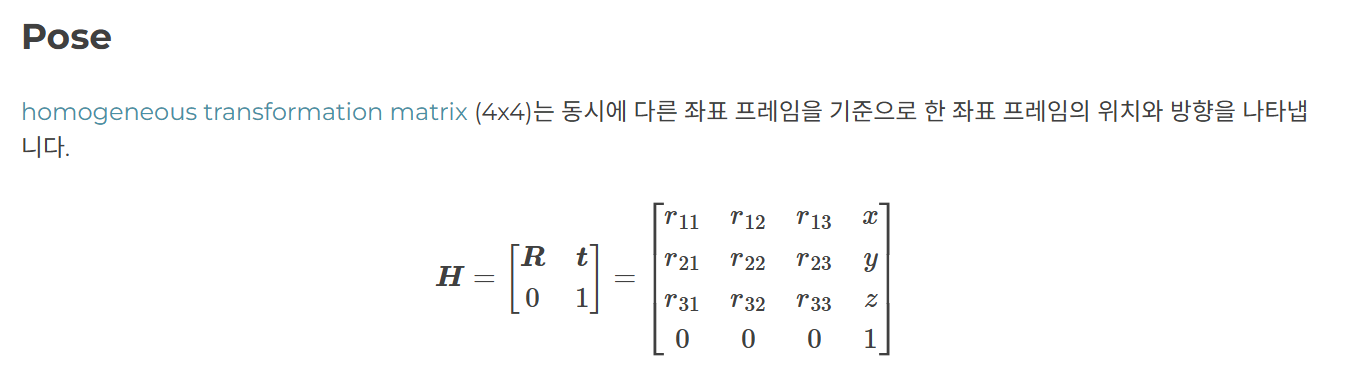

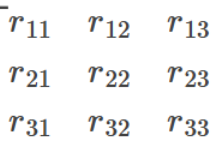

회전행렬 부분(3*3 행렬)
- 첫번째 열(X', r11,r21,r31) 회전한 후 카메라 오른쪽 방향이 월드공간에서 어디를 가리키는가?
- 두번째 열(Y', r12, r22,r32) 회전한 후 카메라 위쪽 방향이 월드공간에서 어디를 가리키는가?  
- 세번째 열(Z', r13, r23, r33) 회전한 후 카메라 정면(렌즈가 보는 곳) 방향이 월드공간에서 어디를 가리키는가?

회전행렬은 회전된 카메라가 갖고 있는 3가지 방향(x,y,z) 3D 좌표

이동벡터 t (3*1)

차원 맞춤형 패딩(padding) [0,0,0,1]
- 원래 (x, y, z) >> (x, y, z, 1)  

(106, 100, 100, 3) (106, 4, 4) 138.88887889922103


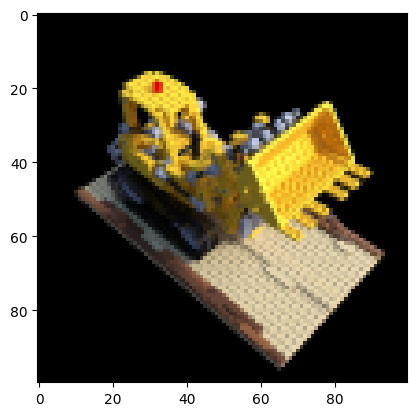

In [3]:
data = np.load('tiny_nerf_data.npz') # NeRF 학습에 필요한 데이터를 NumPy 파일에서 로드
images = data['images']              # RGB 이미지 데이터 (N, H, W, 3)
poses = data['poses']                # 각 이미지에 대한 카메라 포즈 행렬 (N, 4, 4)
focal = data['focal']                # 카메라의 초점 거리 (f)
H, W = images.shape[1:3]             # 이미지의 높이(H)와 너비(W) 추출
print(images.shape, poses.shape, focal) # 로드된 데이터의 형태와 초점 거리 출력 (디버깅/확인용)

# --- 학습 및 테스트 데이터 분리 ---
testimg, testpose = images[101], poses[101] # 102번째 이미지와 포즈를 렌더링 테스트용으로 분리
images = images[:100,...,:3]
# 처음 100개의 이미지를 학습 데이터로 사용 (알파 채널이 있다면 제거하고 RGB만 사용)
# 이미지 데이터 형태 (height, with, channel) 원래 4채널 RGBA >> RGB (A: alpha 투명도)
poses = poses[:100]
# 처음 100개의 포즈를 학습 데이터로 사용

# --- 테스트 이미지 시각화 ---
plt.imshow(testimg)                  # 분리된 테스트 이미지를 Matplotlib으로 화면에 표시
plt.show()                           # 이미지 출력

# 결과 해석
# (106, 100, 100, 3) 106장, 100*100 px, 컬러사진(rgb 3채널)
# (사진개수, 높이, 너비, 색상채널(RGB))
# poses? 각 사진을 찍을 때 카메라 어디에 있었는지 기록
# (106, 4, 4)
# 4*4 행렬(pose matrix)로 3d 공간에서 위치, 방향 표현
# >> 위치, 방향, 변환 정보를 담고 있는 16개의 숫자 정보
# >> 회전, 위치, 이동을 동시에 표현하기 위한 행렬
# 1-9 : 회전(카메라가 어떤 방향을 보고 있나), 10-12(x,y,z), 13-15(항등 좌표계 유지용 값 0,0,0)
# 16 : 항상 1
# focal: 카메라 렌즈 특성, 숫자가 클수록 망원렌즈처럼 확대

# Optimize NeRF

In [4]:
# PyTorch를 실행할 장치(Device)를 설정.
# 'CUDA' (NVIDIA GPU)가 사용 가능하다면 GPU를 사용하고, 아니면 'CPU'를 사용하도록 설정하여 연산 가속화.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PyTorch 텐서의 기본 자료형(Default Data Type)을 32비트 부동 소수점(float32)으로 설정.
# 이는 대부분의 딥러닝 모델에서 표준으로 사용되는 정밀도입니다.
torch.set_default_dtype(torch.float32)

# NeRF 모델에서 사용되는 위치 인코딩(Positional Encoding)의 하이퍼파라미터 L 설정.
# 입력 좌표(x, y, z)를 더 높은 차원으로 매핑하는 데 사용되는 주파수 대역의 수입니다.
# L=6은 NeRF의 세부적인 기하학적 구조를 캡처하는 데 중요한 역할을 합니다.
L_embed = 6

# 위치 인코딩(positional encoding) 함수 (3D 좌표)
# 입력 (x,y,z) 3차원
# 출력 (x,y,z) 3차원 + 36(주파수 변환 각 축마다 sin, cos 존재 L개 생김, 3개축(x,y,z)*L*2(sin,cos))
# >> 39차원 벡터(L6)
# 출력 (x,y,z) 3차원 + 60차원(주파수 변환)  >> 63차원 벡터(L10)

# 예) sin(x): 낮은 주파수(천천히 흔들림, 전체 구조 파악에 용이)
#     sic(16x): 높은 주파스(빠르게 흔들거림, 세밀한 디테일 파악 용이)

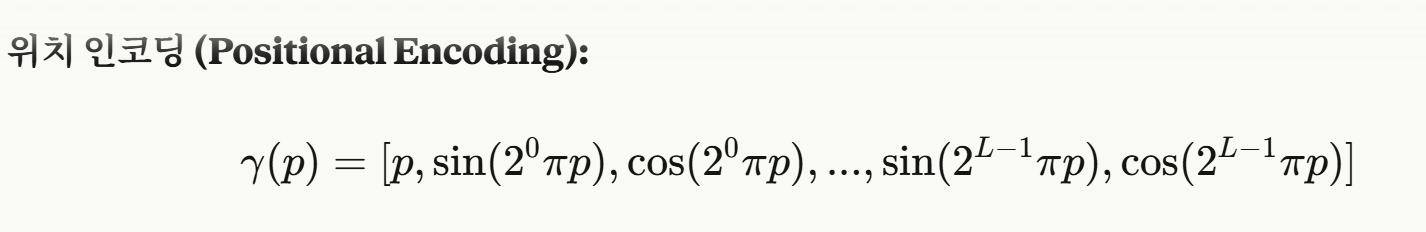

In [5]:
class NeRF(torch.nn.Module):
    """
    NeRF MLP model  # NeRF의 신경 방사 필드(NeRF)를 구현하는 MLP 모델 클래스
    """
    def __init__(self, filter_size=128, L_embed=6):
        super(NeRF, self).__init__()
        # 입력 레이어: (3차원 좌표 + 위치 인코딩된 좌표)를 입력으로 받음.
        # 입력 차원: 3 (원본 xyz) + 3 * 2(sin,cos) * L_embed (인코딩된 sin/cos 쌍)
        self.layer1 = torch.nn.Linear(3 + 3*2*L_embed, filter_size)  #(39, 128)
        self.layer2 = torch.nn.Linear(filter_size, filter_size)      #(128, 128)
        # 출력 레이어: 4차원 (RGB 색상 3차원 + Volume Density(부피 밀도) 1차원)
        self.layer3 = torch.nn.Linear(filter_size, 4)  # (128, 4) >> 4: rgb(색상), sigma(밀도)
        self.relu = torch.nn.functional.relu # 활성화 함수로 ReLU 사용

    def forward(self, x):
        # 3개의 선형 레이어와 2개의 ReLU를 통과하는 순전파 로직
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        # layer1, layer2는 파동(인코딩된 벡터)조합하는 단계
        x = self.layer3(x)
        # 마지막 출력 레이어는 활성화 함수를 적용하지 않음
        # 왜냐하면 밀도는 항상 양수(0보다 커야 함)
        # 색상(rgb) [0,1] (sigmoid) 통과시켜서 값 제한함
        return x


def posenc(x):
    """
    Positional encoding  # 위치 정보에 고주파 정보를 추가하는 함수 (NeRF의 핵심)
    """
    rets = [x] # 원본 좌표(x, y, z)를 결과 리스트에 추가
    # L_embed 만큼의 주파수 대역에 대해 sin과 cos 함수를 적용하여 고차원 벡터 생성
    for i in range(L_embed):   # i = 0,1,2,3,4,5
        for fn in [torch.sin, torch.cos]:
            rets.append(fn(2.0 ** i * x)) # 2^i 주파수로 변환하여 리스트에 추가
    return torch.cat(rets, dim=-1) # 모든 결과를 마지막 차원(-1)으로 연결하여 반환
    # 결과 : [x, sin(x), cos(x), sin(2x), cos(2x).......sin(32x), cos(32x)]

# 함수 결과물? 주파수가 2배씩 증가>> 다양한 스케일의 패턴 포착

embed_fn = posenc # 위치 인코딩 함수에 별칭을 부여하여 이후 사용 편의성 확보

# 왜 주파수(frequency)인가?
# sin, cos >> 파동(1초에 몇 번 흔들리는가, 진동수)
# sin(x) : 낮은 주파수 (천천히 흔들림) cf.sin(16x) 높은 주파수 매우 심하게 (빠르게) 흔들림
# 낮은 주파수: 전체인 구조 파악, 높은 주파수: 디테일 (테두리, 모서리(엣지), 질감)

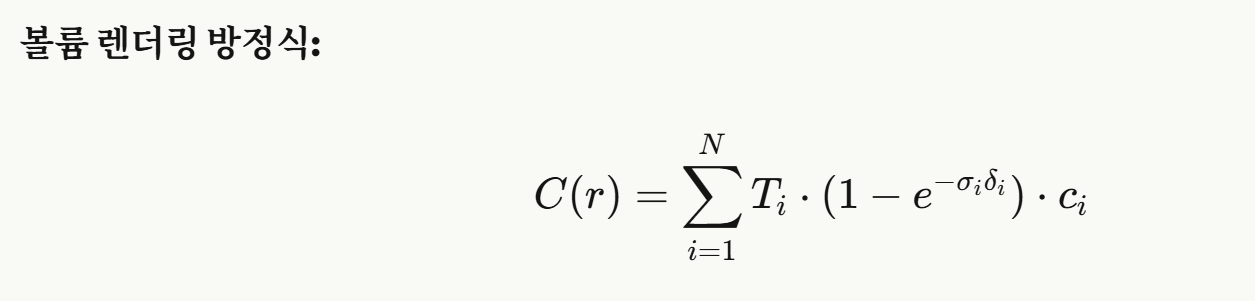

In [19]:
def posenc(x):
    """
    Positional encoding  # 위치 정보에 고주파 정보를 추가하는 함수 (L_embed는 전역 변수로 가정)
    """
    rets = [x] # 원본 좌표(x, y, z)
    # L_embed 주파수 대역에 대해 sin/cos을 적용하여 고차원 벡터 생성
    for i in range(L_embed):
        for fn in [torch.sin, torch.cos]:
            rets.append(fn(2.0 ** i * x))
    return torch.cat(rets, dim=-1) # 결과들을 연결하여 반환

embed_fn = posenc # 위치 인코딩 함수 정의

def get_rays(H, W, focal, c2w):
    """
    Get ray origin, direction to each image pixels based on camera pose
    # 카메라 포즈(c2w: camera to world)를 기반으로 모든 픽셀에 대한 레이의 원점과 방향을 계산
    # 카메라에서 각 픽셀로 광선을 발사하는 함수

    볼룸 렌더링: 광선을 따라 색상을 적분하여 최종 픽셀 색상 계산

    과정:
    1. 광선을 따라 샘플 포인트 생성
    2. 각 포인트에서 색상과 밀도 예측
    3. 볼륨 렌더링 공식으로 최종 색상 계산

    """
    def meshgrid_xy(tensor1, tensor2):
        # PyTorch의 meshgrid 결과를 Numpy/TensorFlow와 호환되도록 재배치
        i, j = torch.meshgrid(tensor1, tensor2, indexing="ij")
        # i, j shape >> (h, w)

        return i.transpose(-1, -2), j.transpose(-1, -2)
        # 전치한 후, (w, h)
        # 그래픽 연산 위해 (x,y) 위해 축 뒤집기 (.transpose)
        # 이미지 좌표 (row, col) 즉 (y, x) >> 그래픽 연산(x, y)

    # 픽셀 좌표 (i, j) 생성

    i, j = meshgrid_xy(
        torch.arange(W, dtype=torch.float32).to(device),
        torch.arange(H, dtype=torch.float32).to(device)
    )
    # 카메라 좌표계(Camera Coordinates)에서의 레이 방향 벡터 계산 (광축: -z)
    dirs = torch.stack([(i-W*0.5)/focal, -(j-H*0.5)/focal, -torch.ones_like(i)], dim=-1).to(device)
    # x축 기울기 (가로)
    # (i-W*0.5)/focal x 방향(중심 기준)
    # pixel 위치를 중심 기준의 거리로 변경한 후, 초점거리(focal) 나눔>>각도(기울기)

    # y축 기울기 (세로)
    # -(j-H*0.5)/focal y방향 (위가 음수)
    # 이미지(2차원) y좌표 아래로 갈 수록 커짐, 3D 공간 y축은 위로 갈수록 커짐
    # 그렇다면 - (마이너스) 부호는? 마이너스 붙여야 같은 방향

    # z축 고정값(정면 방향)
    # -torch.ones_like(i)] (카메라 앞쪽) 카메라가 바라보는 정면 방향 (-z 방향)
    # OpenCV 3D 그래픽스 표준 : 카메라는 -Z 방향(모니터 안쪽 깊숙한 곳)을 정면으로 바라보게 설계했기 때문
    # 레이 방향: 카메라 좌표를 월드 좌표로 변환 (회전 행렬 c2w[:3, :3] 사용)
    # 카메라 방향 회전 (dirs.shape = (H, W, 3), 여기서 3은 [dx, dy, dz] 방향 벡터)
    # >> dirs[h,w] = [dx, dy, dz]
    rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], dim=-1)
    # '...' 이게 뭐야? 앞 차원 전부 가져와
    # dirs[...,:] = dirs[:,:,:] >> 여기에 차원 하나 추가 (새로운 차원 하나 추가)
    # 슬라이싱 자리에 None 이 붙으면 그 자리에 크기가 1인 새로운 차원 강제로 생성
    # dirs[..., None, :] (h, w, 1, 3)  == dirs[:,:, None, :] >> 방향 벡터
    # c2w[:3, :3] 크기 회전행렬 (3,3)
    # 브로드 캐스팅 통해 계산이 됨

    # shape 변화 추적
    # 레이 원점(카메라 위치, 광선 시작점)
    # 카메라 위치 (c2w[:3, -1]) c2w 행렬에서 x,y, z 를 모든 레이 방향의 수만큼 확장
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    # 4*4 행렬 마지막 (맨 오른쪽) 열
    # (카메라가 월드좌표계 어디에 있는지 알려줌: 카메라 실제위치)(x,y,z 좌표) >> 이동 값)
    # 모든 광선은 카메라 위치에서 시작함 >> expand 모든 픽셀에 대해 동일한 시작점 부여해서 확장
    return rays_o, rays_d # 월드 좌표계에서의 레이 원점과 방향 반환
    # 결론: 모든 픽셀에 대해 광선(ray)가 시작되는 월드좌표 할당해라

# NeRF 모델로 광선 따라 볼륨렌더링 수행
def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, rand=False):
    """
    Volume rendering # NeRF 모델을 사용하여 샘플링된 점들을 따라 볼륨 렌더링을 수행
    >> 쉽게 말하자면, 광선(ray) 따라서 색상 계산해줘
    >> 이거 다음에 뭐해? 각 점의 색상(rgb), 밀도 나오면 그거 가지고 가중평균해서 최종색 계산
    """
    def batchify(fn, chunk=1024*32):
        # 메모리 효율을 위해 대량의 입력을 청크(chunk)로 나누어 MLP를 호출
        # fn: 실제 계산할 함수(mlp), chunk(한 번에 처리할 최대 입력 수) = 32768
        return lambda inputs : torch.cat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], dim=0)
        # inputs 100,000개
        # 1번째 : inputs[0: 32768]
        # 2번째 : inputs[32768:65536]
        # 3번째 : inputs[65536:98304]
        # 4번째: inputs[98304:100,000]
        # 이렇게 4번째 잘라서 fn(mlp) 넣는다
        # 최종 결과물은 원래 입력길이와 동일한 구조로 복원

    def exclusive_cumprod(tensor):
        # 누적 곱을 계산한 뒤 한 칸 오른쪽으로 시프트하여 T_i (투과율) 계산에 사용
        # 배타적 누적 곱 : i 번째 위치의 값은 자기 자신을 곱하지 않은 이전 값들의 누적 곱임
        cumprod = torch.cumprod(tensor, dim=-1)
        cumprod = torch.roll(cumprod, 1, dims=-1)
        cumprod[..., 0] = 1.0 # 첫 번째 값은 1.0으로 설정 (첫 번째 샘플까지의 투과율)
        return cumprod
        # T_i (투과율) i번째 이전 값들의 누적 곱만 포함하고 , 자기자신 alpha_i(샘플의 불투명도)포함
        # 즉, 각 샘플의 투과율 (T_i) 자기 이전의 샘플들만 누적
        # [ 0.7, (0.7*0.5), (0.7*0.5*0.8)] >> (roll 1칸 밀어) >> [0.28, 0.7,0.35)]
        # >> ... : 무시하고 첫번째 값 (0) 초기화 해  [ 1, 0.7, 0.35]
        # 여기에 투과율(살아 남아서 내 눈앞에 보이는 거) 그 지점의 색깔(rgb), 불투명도(alpha) 곱해요
        # >> 이것이 볼륨 렌더링이다.

    # --- 3D 쿼리 점 계산 (Sample 3D Points) ---
    z_vals = torch.linspace(near, far, N_samples).to(device) # 레이를 따라 균일하게 깊이 값(z) 생성
    if rand:
        # 훈련 시 정규화를 방지하기 위해 랜덤한 오프셋 추가 (Hierarchical Sampling 이전 단계)
        z_vals = z_vals + torch.rand(list(rays_o.shape[:-1]) + [N_samples]).to(device) * (far-near)/N_samples
        # rand() : 0-1 난수
        # rays_o.shape = (1024, 3) >> [:-1] >> (1024, ) >> (1024,N_samples)
        # ray(광선)마다 n개 난수 생성
        # (far-near) 전체 구간, (far-near)/N_samples : 각 샘플당 차지하는 구간 >> 각 샘플 간 간격

    # 3D 점 좌표 계산: pts = o + t * d (레이 원점 + 깊이 * 레이 방향)
    # 카메라 쏜 광선을 따라가면서 z_vals 깊이에 해당하는 3d 점들 생성
    # None 차원확장 역할
    # 2차원을 3차원으로 만드는 과정
    # rays_o, rays_d : (n_rays 광선개수, 3 (x,y,z))
    # 장원영 등신대 갖고 싶어. 나에게는 장원영 포토카드가 있어.
    # 포토카드의 pixel을 이용해서 광선 100개 만들었어. (100개의 광선이 있고, 각각 (x,y,z) 위치 정보 있어)
    # z_vals (n_rays 광선개수, n_samples ) 각 광선마다 100개의 점 찍을 수 있어.
    # rays_o[..., None, :] (n_rays, 1, 3)
    # z_vals[..., :, None] (n_rays, n_samples, 1 )
    # 광선 하나 당 샘플 100개 점 전부 대응해서 계산해줘.

    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]
    # 해당 공간의 3d 점 = 카메라 위치 + (방향 * 거리)
    # (방향 * 거리) >> 어느 방향으로 얼마나 보낼까
    # rays_o[..., None, :] (h,w,3) >> (N-rays, 3) >> (N-rays, 1, 3)
    # rays_d[..., None, :] rays_d : 각 광선의 1unit 당 direction(방향) 벡터 (길이 1 방향 벡터)
    # >> (N-rays, 1, 3)
    # z_vals[..., :, None] 깊이 샘플값(N_samples) (N_rays, N_samples, 1)
    # rays_d[..., None, :] * z_vals[..., :, None]
    # (N-rays, 1, 3) * (N_rays, N_samples, 1)
    # >> 각 ray(광선) 방향을 z(distance) 만큼 이동한 3d 좌표 변화량
    # >> 쉽게 말하자면 장원영 등신대 만들기 위해 100개의 광선을 쏴서
    #    그 각각의 광선이 100개씩 찍힌 점들의 (x, y, z)좌표

    # --- NeRF MLP 실행 (Run Network) ---
    pts_flat = torch.reshape(pts, [-1, 3]) # 3D 점들을 평탄화하여 MLP 입력 형태로 만듦
    # (N_rays, N_samples, 3) >> (batch_size, 3)  # batch_size, [x,y,z]
    pts_flat = embed_fn(pts_flat) # 위치 인코딩 적용
    raw = batchify(network_fn)(pts_flat) # NeRF MLP를 청크 단위로 실행
    raw = torch.reshape(raw, list(pts.shape[:-1]) + [4])
    # 결과를 (레이 수, 샘플 수, 4) 형태로 복원
    # 4 가 뭐지? (r, g, b), d (density: 밀도)
    # mlp 통과하면 (N_samples, 4)


    # --- Opacities and Color (색상 및 밀도 추출) ---
    sigma_a = torch.nn.functional.relu(raw[..., 3])
    # raw[..., 3] 3: density (밀도=질량/부피) 밀도는 음수가 될 수 없어
    # relu 통과 시키면, 음수 >> 0 만들어 줌
    # 부피 밀도(sigma): ReLU를 적용하여 양수로 만듦

    rgb = torch.sigmoid(raw[..., :3])
    # 색상(RGB): 시그모이드(Sigmoid)를 적용하여 [0, 1] 범위로 만듦
    # rgb [0,255] >> torch 형태 [0,1]

    # --- 볼륨 렌더링 공식 적용 (Perform Volume Rendering) ---
    # 인접 샘플 간의 거리 계산 (마지막은 무한대로 가정)
    dists = torch.cat([z_vals[..., 1:] - z_vals[..., :-1],
                       torch.tensor([1e10], device=device).expand(z_vals[..., :1].shape)], dim=-1)
    # z_vals : 광선(ray) 을 따라 샘플링한 깊이 값 (인접한 두 점의 차이 = 거리)
    # 1e10 (10^10) >> 사실상 무한대
    # z_vals.shape (N_rays, N_sampes)  >> z_vals[..., :1]  (N_rays, 1)


    # 투과율(T)과 밀도(sigma)를 사용하여 알파 값(가중치) 계산: alpha = 1 - exp(-sigma * delta)
    # 밀도 =질량 / 부피 >> 밀도가 높으면 빛이 더 많이 막힌다 >> alpha가 높아진다
    # 밀도가 0 >> 아무 것도 없다 >> alpha=0

    # 밀도(sigma)와 두께(dists)가 만난다 >>> 불투명도(alpha)
    alpha = 1.0 - torch.exp(-sigma_a * dists)
    # 밀도 * 두께/부피(dist)=질량(장애물) 크면 alpha(불투명도) >> 1에 가까워짐 (빛이 소멸)

    # 빛의 나까자 오는데 살아남는 생존력과 불투명도의 관계 (weights)
    # 볼륨 렌더링 가중치 계산: weight = T * alpha
    # 누적 투과율 사용
    weights = alpha * exclusive_cumprod(1.0-alpha + 1e-10)
    # 1.0-alpha 투과율 : 빛이 막히지 않고 통과할 확률
    # exclusive_cumprod(1.0-alpha + 1e-10) >> 맨 첫칸은 무조건 1.0
    # 최종 색상 (RGB Map) 계산: C = sum(weight * color)
    # >> 볼륨 렌더린 된 최종 색상
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    # weights: (n_rays, n_samples), rgb (n_rays, n_samples, 3(rgb))
    # weights: (n_rays, n_samples) >> weights: (n_rays, n_samples, 1) 차원추가
    # dim=-2 >> n_samples
    # 지워버릴 축은 n_samples >> 이 축을 기준으로 싹 더해버려
    # >> n_samples 차원에 맞추어서 광선을 따라 만들어진 100개의 점을 다 더해서 하나로 합쳐줘
    # >> 결과물 (n_rays, 3)

    # 깊이 맵 (Depth Map) 계산: D = sum(weight * z_val)
    # 각 샘플 z 위치에 가중치를 곱한 뒤 합해주는 거네
    # >> 빛이 많이 닿는 위치일 수록 깊이에 반영되겠네
    depth_map = torch.sum(weights * z_vals, dim=-1)
    # weights (n_rays, n_samples) , z_vals  (n_rays, n_samples)
    # >> (n_rays, ) >> 픽셀 당 하나의 거리 값

    # 누적 투과율 (Accumulation Map) 계산: Acc = sum(weight)
    # 과연 이 광선은 물체를 만났는가? 아니면 그냥 허공에 날렸는가?
    acc_map = torch.sum(weights, dim=-1)
    # 크기는 (n_rays, )
    # 누적 투과율 acc_map (광선을 따라 존재하는 모든 가중치 다 더해)
    # 투과율이 높으면 전체 값이 낮아짐

    return rgb_map, depth_map, acc_map # 최종 렌더링된 색상, 깊이, 누적 투과율 반환

Here we optimize the model. We plot a rendered holdout view and its PSNR every 50 iterations.

In [20]:
data = np.load('tiny_nerf_data.npz') # NumPy 파일에서 NeRF 데이터 로드
images = data['images']
poses = data['poses']
focal = data['focal']

# NumPy 데이터를 PyTorch Tensor로 변환하고 GPU/CPU 장치로 이동
images = torch.from_numpy(images).to(device)
poses = torch.from_numpy(poses).to(device)
focal = torch.from_numpy(focal).to(device)

H, W = images.shape[1:3] # 이미지 높이(H)와 너비(W) 추출

# Define test set, training set
testimg, testpose = images[101], poses[101] # 102번째 데이터를 테스트용으로 분리
images = images[:100,...,:3] # 처음 100개 이미지를 학습 데이터로 사용 (RGB만)
poses = poses[:100] # 처음 100개 포즈를 학습 데이터로 사용

# Hyperparameters
N_samples = 64 # 각 광선(Ray)을 따라 샘플링할 3D 점의 개수
N_iters = 10000 # 총 학습 반복 횟수 (Iteration)
psnrs = [] # PSNR 값 기록 리스트(테스트 이미지의 psnr 값 저장)
iternums = [] # 반복 횟수 기록 리스트
i_plot = 100 # 테스트 이미지 렌더링 및 시각화 빈도
lr = 5e-3 # 학습률 (Learning Rate)

# psnr (peak signal to noise ratio)
# 이미지 품질 평가 지표
# mse 이 적을 수록 에러가 적어짐
# >> psnr 은 증가한다
# 잡음(noise) 대비 진짜 신호(원본) 비율이 얼마나 크냐 계산
# psnr 높다면 잡음이 적은 깨끗한 고화질 이미지

# Define NeRF model, optimizer
model = NeRF() # NeRF MLP 모델 생성
model = model.to(device) # 모델을 지정된 장치(GPU/CPU)로 이동
optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Adam 옵티마이저 정의

# NeRF optimization loop
print("NeRF optimization start")
plot_image = True # 시각화 여부 플래그

for i in tqdm(range(N_iters)): # 설정된 반복 횟수만큼 학습 루프 시작 (tqdm으로 진행 상황 표시)
    img_i = np.random.randint(images.shape[0]) # 학습 데이터에서 무작위로 하나의 이미지 인덱스 선택
    target = images[img_i].to(device) # 타겟 이미지 (정답)
    pose = poses[img_i].to(device) # 해당 이미지의 카메라 포즈

    # 1. Ray Generation: 무작위로 선택된 포즈에서 나오는 모든 광선(rays) 계산
    # 카메라 좌표계에서 각 픽셀방향으로 광선을 쏜다
    rays_o, rays_d = get_rays(H, W, focal, pose)

    # 2. Volume Rendering: 광선을 따라 3D 샘플링 및 NeRF 모델 쿼리 후 렌더링
    # rand=True를 사용하여 훈련 시 샘플링 깊이에 무작위 오프셋 추가 (노이즈 방지)
    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2.0, far=6.0, N_samples=N_samples, rand=True)
    # 각 ray(광선) 따라서 64개 점 샘플링
    # NeRF MLP 통과 >> 각각의 색상, 밀도 예측
    # 볼륨렌더링 최종 C(rgb), depth

    # Back propagation
    # 3. Loss Calculation: 렌더링된 RGB와 타겟 이미지 간의 MSE 손실 계산
    loss = torch.nn.functional.mse_loss(rgb, target)
    loss.backward() # 역전파 (기울기 계산)
    optimizer.step() # 옵티마이저를 통해 모델 파라미터 업데이트
    optimizer.zero_grad() # 다음 반복을 위해 기울기 초기화

    if plot_image:
        if i % i_plot == 0: # i_plot 간격마다 테스트 및 시각화 수행
            # --- Test Rendering (Evaluation) ---
            # 테스트 포즈를 사용하여 광선 계산 (rand=False로 확정적 샘플링)
            rays_o, rays_d = get_rays(H, W, focal, testpose)
            # 테스트 이미지 렌더링
            rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2.0, far=6.0, N_samples=N_samples)

            # --- PSNR Calculation ---
            loss = torch.nn.functional.mse_loss(rgb, testimg) # 테스트 이미지와의 손실
            # PSNR(Peak Signal-to-Noise Ratio) 계산: 이미지 품질 측정 지표
            psnr = -10.0 * torch.log10(loss)

            # --- Record ---
            psnrs.append(psnr.item())
            iternums.append(i)

            # --- Visualization ---
            plt.figure(figsize=(12, 4))

            # 렌더링된 RGB 이미지 시각화
            plt.subplot(131)
            plt.imshow(rgb.cpu().detach().numpy())
            plt.title(f"Iteration {i}")

            # PSNR 변화 그래프 시각화
            plt.subplot(132)
            plt.plot(iternums, psnrs)
            plt.title("PSNR")

            # 렌더링된 깊이 맵(Depth Map) 시각화
            plt.subplot(133)
            plt.imshow(depth.cpu().detach().numpy(), cmap="gray")
            plt.title("Depth Map")

            # 플롯 창 자동 닫기 설정
            plt.show(block=False)
            plt.pause(1) # 1초 동안 잠시 화면 표시
            plt.close() # 플롯 창 닫기 (메모리 관리)

print("Done")

Output hidden; open in https://colab.research.google.com to view.

# Interactive Visualization

In [21]:
save_video = True # 영상 저장 활성화 플래그 (현재는 비활성화)
if save_video:
    print("Video save start")
    import imageio # 영상 파일 생성에 필요한 라이브러리 임포트

    # --- 카메라 포즈 변환 행렬 정의 ---
    # NeRF에서 자주 사용되는 카메라 포즈를 쉽게 계산하기 위한 헬퍼 함수
    trans_t = lambda t : np.array([ # Z축 평행 이동(Translation) 행렬
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, t], # z축(방향)으로 t만큼 이동
        [0, 0, 0, 1]
    ], dtype=np.float32)
    # (x,y,z) >> 원점(0,0,0)
    # 카메라를 원점에서 z 축 방향으로 radius 만큼 떼어 놓는 것
    # 카메라를 z축으로 뒤로 빼서 어느정도 거리(멀리서) 바라보게 하는 것

    rot_phi = lambda phi : np.array([ # X축 회전 (Rotation around X) 행렬 (phi 각도)
        [1, 0, 0, 0],
        [0, np.cos(phi), -np.sin(phi), 0],
        [0, np.sin(phi), np.cos(phi), 0],
        [0, 0, 0, 1]
    ], dtype=np.float32)
    # 점을 x축 기준, phi radian 만큼 회전

    rot_theta = lambda th : np.array([ # Y축 회전 (Rotation around Y) 행렬 (theta 각도)
        [np.cos(th), 0, -np.sin(th), 0],
        [0, 1, 0, 0],
        [np.sin(th), 0, np.cos(th), 0],
        [0, 0, 0, 1]
    ], dtype=np.float32)
    # 점을 y 축 기준, theta radian 만큼 회전 (카메라를 좌우 회전)

    def pose_spherical(theta, phi, radius):
        # 구형 궤적(Spherical trajectory)을 따라 카메라 포즈(c2w)를 계산
        c2w = trans_t(radius)                                   # 1. z축으로 이동 (반지름 r)
        # 구의 반지름 r 만큼 떨어진 위치에 카메라 두는 첫 단계
        c2w = rot_phi(phi/180.0*np.pi) @ c2w                    # 2. x축 회전 (phi)
        # phi/180.0*np.pi >> radian
        # x축 회전 행렬 >> 카메라를 위, 아래로 회전
        c2w = rot_theta(theta/180.0*np.pi) @ c2w                # 3. y축 회전 (theta)
        # y축 회전 행렬 >> 카메라를 좌, 우로 회전

        # 4. 카메라 축 맞추기: NeRF에서 사용되는 표준 좌표계로 변환 (look-at-origin)
        # 논문에서 사용한 카메라 좌표계 표준에 맞추는 보정 행렬
        c2w = np.array([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]]) @ c2w
        return torch.from_numpy(c2w).float().to(device) # PyTorch 텐서로 변환하여 반환

    frames = [] # 렌더링된 이미지를 저장할 리스트

    # --- 영상 프레임 생성 루프 ---
    # 0도부터 360도까지 120개의 프레임을 생성
    for th in tqdm(np.linspace(0.0, 360.0, 120, endpoint=False)):
        c2w = pose_spherical(th, -30.0, 4.0) # 구 궤도를 따라 다음 카메라 포즈 계산
        # th : 현재 각도(degree), phi=-30: 약간 위에서 아래로 내려다 보는 각도
        # radius: 4 원점에서 카메라까지 거리

        # Ray Generation & Volume Rendering
        # 계산된 포즈를 사용하여 광선(rays)을 얻고, 모델로 이미지를 렌더링
        rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
        # c2w[:3,:4] 4*4행렬에 (3*4) 부분만 사용 (카메라 좌표 >> 월드좌표 변환에서 사용하는 부분)
        # rays_o, rays_d : 광선(ray) 시작점과 방향 계산

        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2.0, far=6.0, N_samples=N_samples)
        # hc 가 가라사대
        # rgb(이미지 색상), depth(깊이맵), acc(누적 투과율) 생성

        # 렌더링된 RGB를 영상 저장을 위해 NumPy 배열로 변환 및 정규화 ([0, 255] uint8)
        rgb = rgb.cpu().detach().numpy()
        frames.append((255*np.clip(rgb,0,1)).astype(np.uint8))

    # --- 영상 저장 ---
    f = '/content/video.mp4' # 저장할 파일 경로
    imageio.mimwrite(f, frames, fps=30, quality=7)
    # imageio를 사용하여 프레임들을 mp4 영상 파일로 저장 (30fps)
    print("Done")

Video save start


100%|██████████| 120/120 [00:02<00:00, 51.29it/s]


Done


# Render 360 Video

In [22]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = pose_spherical(th, -30., 4.)

    # c2w가 GPU로 이동되었는지 확인 후 슬라이싱 (이전 에러 해결을 위해 pose_spherical 내부에 .to(device) 필요)
    # get_rays 함수에 필요한 c2w는 이미 GPU에 있다고 가정합니다.
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])

    rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=N_samples)

    # 텐서를 GPU에서 분리(.detach())하고 CPU로 이동(.cpu())한 후, NumPy 배열로 변환합니다.
    rgb_np = rgb.cpu().detach().numpy()

    # NumPy 배열을 사용하여 영상 프레임 데이터 (0-255 uint8)를 생성
    frames.append((255 * np.clip(rgb_np, 0, 1)).astype(np.uint8))

import imageio
f = 'video.mp4'
imageio.mimwrite(f, frames, fps=30, quality=7)

100%|██████████| 120/120 [00:02<00:00, 51.16it/s]


In [23]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('video.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

이해하기 위한 노력 (실습)

In [14]:
def exclusive_cumprod(tensor):
        # 누적 곱을 계산한 뒤 한 칸 오른쪽으로 시프트하여 T_i (투과율) 계산에 사용
        # 배타적 누적 곱 : i 번째 위치의 값은 자기 자신을 곱하지 않은 이전 값들의 누적 곱임
        cumprod = torch.cumprod(tensor, dim=-1)
        cumprod = torch.roll(cumprod, 1, dims=-1)
        cumprod[..., 0] = 1.0 # 첫 번째 값은 1.0으로 설정 (첫 번째 샘플까지의 투과율)
        return cumprod

In [15]:
import torch

data = [1,2,3,4]

tensor = torch.tensor(data)
print(tensor)
print()
cumprod = torch.cumprod(tensor, dim=-1)
print(cumprod)
# 1, 1*2, 1*2*3, 1*2*3*4
print()
# 위 cumprod (누적곱) 오른쪽으로 한 칸 밀어버려
cumprod_roll = torch.roll(cumprod, 1, dims=-1)
print(cumprod_roll)
# 1*2*3*4, 1, 1*2, 1*2*3
print()

cumprod_roll[..., 0] = 1.0
 # 첫 번째 값은 1.0으로 설정 (첫 번째 샘플까지의 투과율)
print(cumprod_roll)


print(exclusive_cumprod)
# 원래 tensor tensor([1, 2, 3, 4])
# cumprod(누접 곱) tensor([ 1,  2,  6, 24]) 자기 자신이 포함
# cumprod_roll tensor([24,  1,  2,  6])
# exclusive_cumprod ([1 1 2 6])

tensor([1, 2, 3, 4])

tensor([ 1,  2,  6, 24])

tensor([24,  1,  2,  6])

tensor([1, 1, 2, 6])
<function exclusive_cumprod at 0x7c002d0a5da0>


ray tracing vs. ray marching

- ray tracing : mesh 필요함
- 광선(ray) 쏴요 >> 표면(surface) 정확하게 맞출때까지 진행
- 반사, 그림자 계산
- 반드시 명확한 기하학적 모델(mesh) 필요함

- NERF는 MESH 없음
- ray marching
- 광선 쏴요 >> 광선 따라서 일정 간격으로 여러 점(pts) 샘플링
- 각 점에서 mlp (신경망) 통과 >> 색(rgb), 밀도
- 이를 계산하기 위해서 볼룸 렌더링 공식 이용  

In [ ]:
# EOS

추가 보충 실습

In [6]:
def meshgrid_xy(tensor1, tensor2):
        # PyTorch의 meshgrid 결과를 Numpy/TensorFlow와 호환되도록 재배치
        i, j = torch.meshgrid(tensor1, tensor2, indexing="ij")
        return i.transpose(-1, -2), j.transpose(-1, -2)
        # 이미지 좌표 (row, col) 즉 (y, x) >> 그래픽 연산(x, y)

In [12]:
import torch

# 세로(H) 좌표축을 담당하는 텐서 (행의 개수 3)
tensor1 = torch.tensor([0,1,2])
# 가로(W) 좌표축을 담당하는 텐서(열의 개수 2)
tensor2 = torch.tensor([0,1])

# 결과물 i, j 모두 (H,W) (3,2) 행렬
i, j = torch.meshgrid(tensor1, tensor2, indexing='ij')

print(i)
print(i.shape)
print()
print(j)
print(j.shape)

tensor([[0, 0],
        [1, 1],
        [2, 2]])
torch.Size([3, 2])

tensor([[0, 1],
        [0, 1],
        [0, 1]])
torch.Size([3, 2])


In [13]:
i_t = i.transpose(-1, -2)
j_t = j.transpose(-1, -2)

print(i_t)
print(i_t.shape)
print()
print(j_t)
print(j_t.shape)

tensor([[0, 1, 2],
        [0, 1, 2]])
torch.Size([2, 3])

tensor([[0, 0, 0],
        [1, 1, 1]])
torch.Size([2, 3])
